In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tqdm.contrib.itertools import product
from collections import Counter

# NDLib stuff
import networkx as nx
import ndlib.models.epidemics as ep
import ndlib.models.ModelConfig as mc

# Seeding rng
import random
np.random.seed(14105071)
random.seed(14105071)

# Matplotlib Stuff
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = [4,4]

no display found. Using non-interactive Agg backend


In [2]:
def model_trend(model, beta, gamma, fraction_infected, n_iterations):
    # Manually achieve the trends to allow comparison numerically
    cfg = mc.Configuration()
    cfg.add_model_parameter('beta', beta)
    cfg.add_model_parameter('gamma', gamma)
    cfg.add_model_parameter('fraction_infected', fraction_infected)

    model.set_initial_status(cfg)
    iterations = model.iteration_bunch(n_iterations)
    trends = model.build_trends(iterations)
    
    s = trends[0]['trends']['node_count'][0]
    i = trends[0]['trends']['node_count'][1]
    r = trends[0]['trends']['node_count'][2]
    t = np.arange(0, len(s), 1)
    return [s, i, r, t]

In [3]:
model = ep.SIRModel(nx.erdos_renyi_graph(1000, 0.1))
_ = model_trend(model, 0.1, 0.001, 0.05, 200)

In [4]:
class Graph_generator():
    def __init__(self) -> None:
        self.number_of_nodes = 0
        self.probability_of_connection = 0
        self.number_of_edges = 0
        self.number_of_neighbors = 0
        self.graph_type = "er" # options are "er", "ba", "ws"

    def analyse_graph(self, graph):
        C = nx.average_clustering(graph)
        try:
            d = nx.diameter(graph)
        except:
            d = np.inf
        l = nx.average_shortest_path_length(graph)
        degree_histogram = nx.degree_histogram(graph)
        return [C, d, l, np.array(degree_histogram)]

    def create_graph(self):
        if self.graph_type == "er":
            return nx.erdos_renyi_graph(self.number_of_nodes, self.probability_of_connection)
        elif self.graph_type == "ba":
            return nx.barabasi_albert_graph(self.number_of_nodes, self.number_of_edges)
        elif self.graph_type == "ws":
            return nx.connected_watts_strogatz_graph(self.number_of_nodes, self.number_of_neighbors, self.probability_of_connection)
    
    def batch_analysis(self, N, p=[0], m=[0], k=[0], graph_type="er", iterations=1):
        C_lst = []
        d_lst = []
        l_lst = []
        deg_lst = []
        params = []
        graphs= []
        self.graph_type = graph_type
        for (nodes, probability, edges, neighbors) in product(N, p, m, k):
            self.number_of_nodes = nodes
            self.probability_of_connection = probability
            self.number_of_edges = edges
            self.number_of_neighbors = neighbors
            C_prime =[]
            l_prime =[]
            d_prime =[]
            deg_prime = []
            graphs_prime = []
            for i in range(iterations):
                graph = self.create_graph()
                C, d, l, deg = self.analyse_graph(graph)
                C_prime.append(C)
                d_prime.append(d)
                l_prime.append(l)
                deg_prime.append(deg)
                graphs_prime.append(graph)
            C_lst.append(C_prime)
            d_lst.append(d_prime)
            l_lst.append(l_prime)
            deg_lst.append(deg_prime)
            params.append({
                "N": nodes,
                "p": probability,
                "m": edges,
                "k": neighbors,
            })
            graphs.append(graphs_prime)
        return C_lst, d_lst, l_lst, deg_lst, params, graphs 

In [5]:
gen = Graph_generator()

In [6]:
# compare erdos-renyi graphs
N_vals = [100, 500, 1000]
p_vals = [0.1, 0.2, 0.3]

C_lst, d_lst, l_lst, deg_lst, params, _ = gen.batch_analysis(N=N_vals, p=p_vals, graph_type="er", iterations=5)
graph_er = _[-1][-1]

  0%|          | 0/9 [00:00<?, ?it/s]

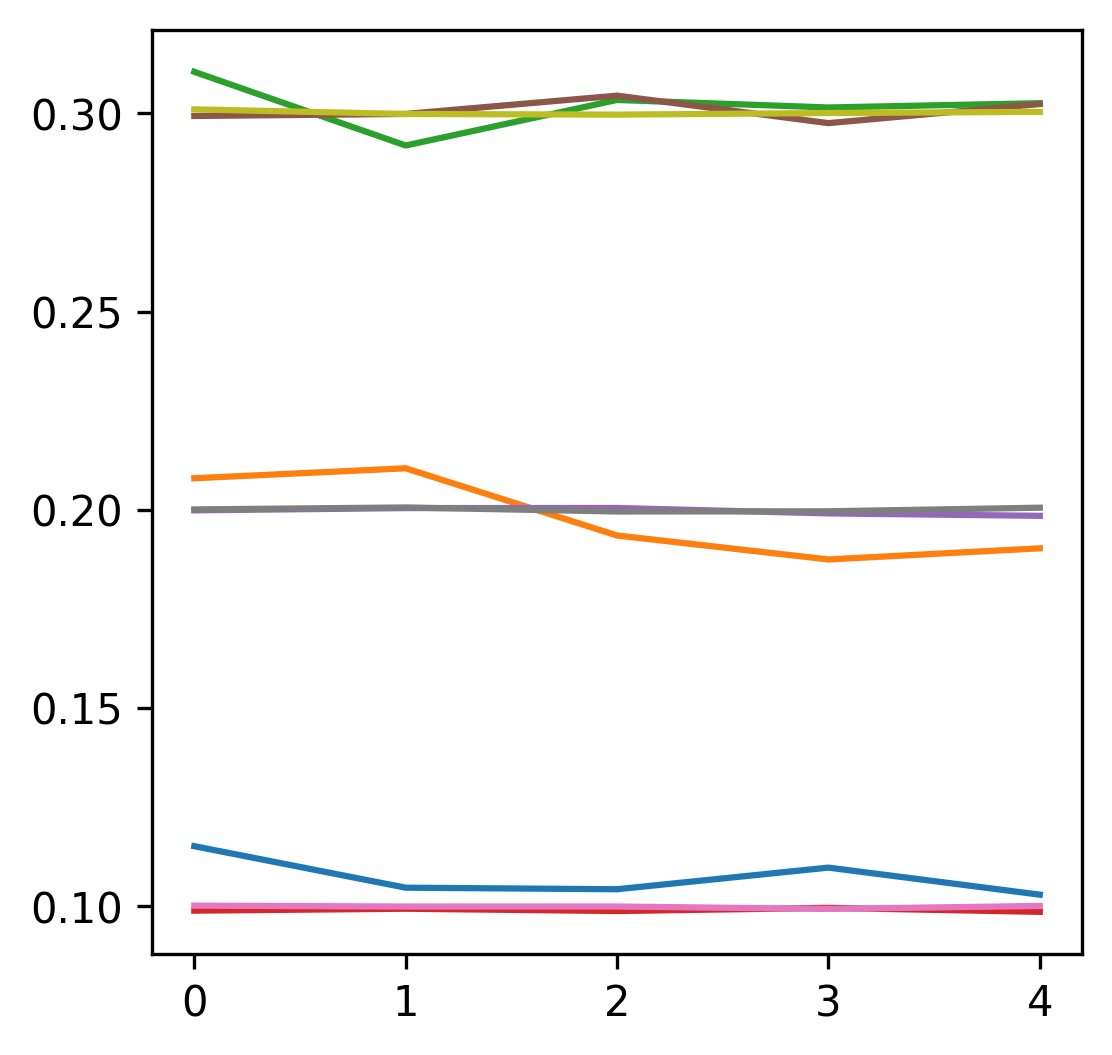

[0.3010166047205147,
 0.2998530083481641,
 0.2996892384365262,
 0.300088401180608,
 0.3003839000636051]

In [7]:
for C in C_lst:
    plt.plot(range(len(C)), C)
plt.show()
C

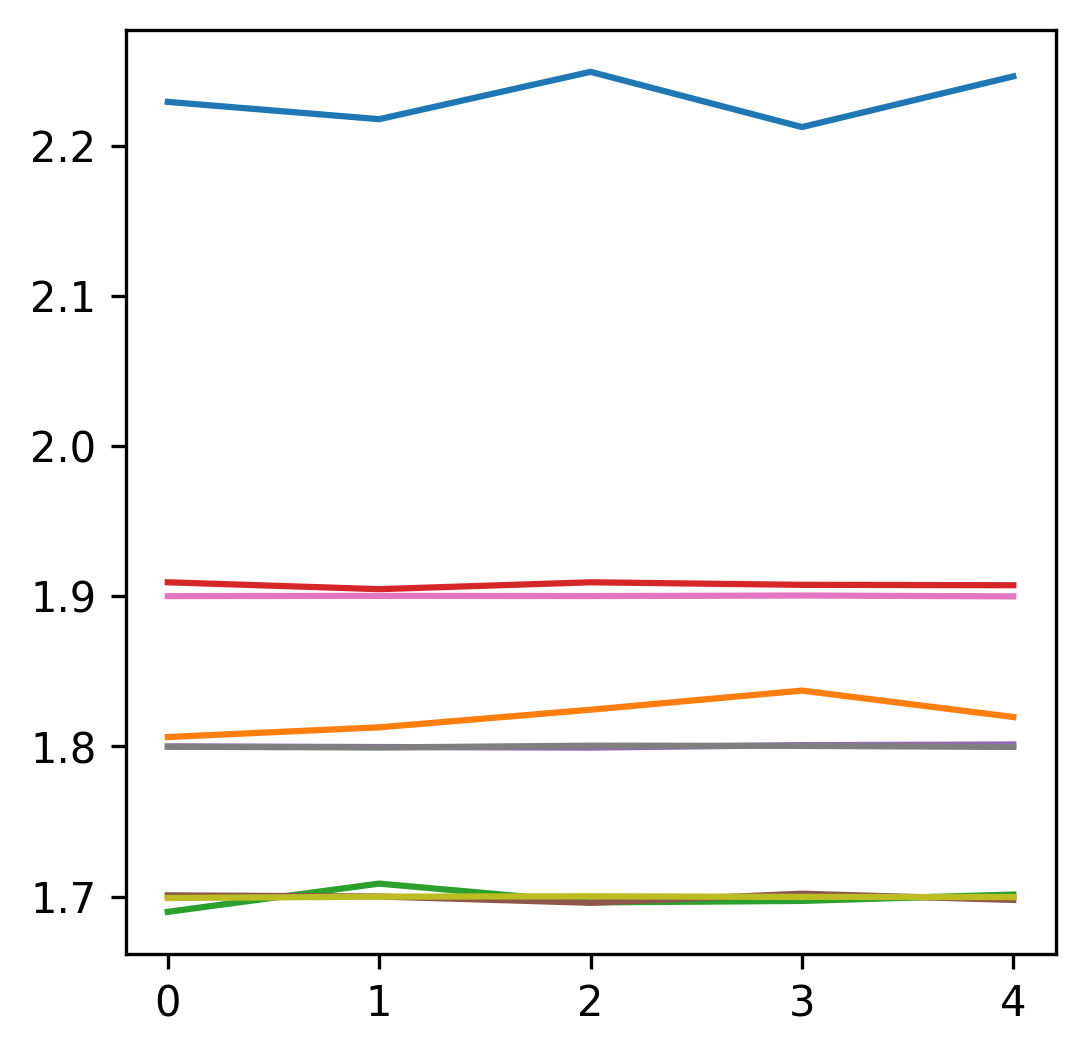

In [8]:
for l in l_lst:
    plt.plot(range(len(l)), l)

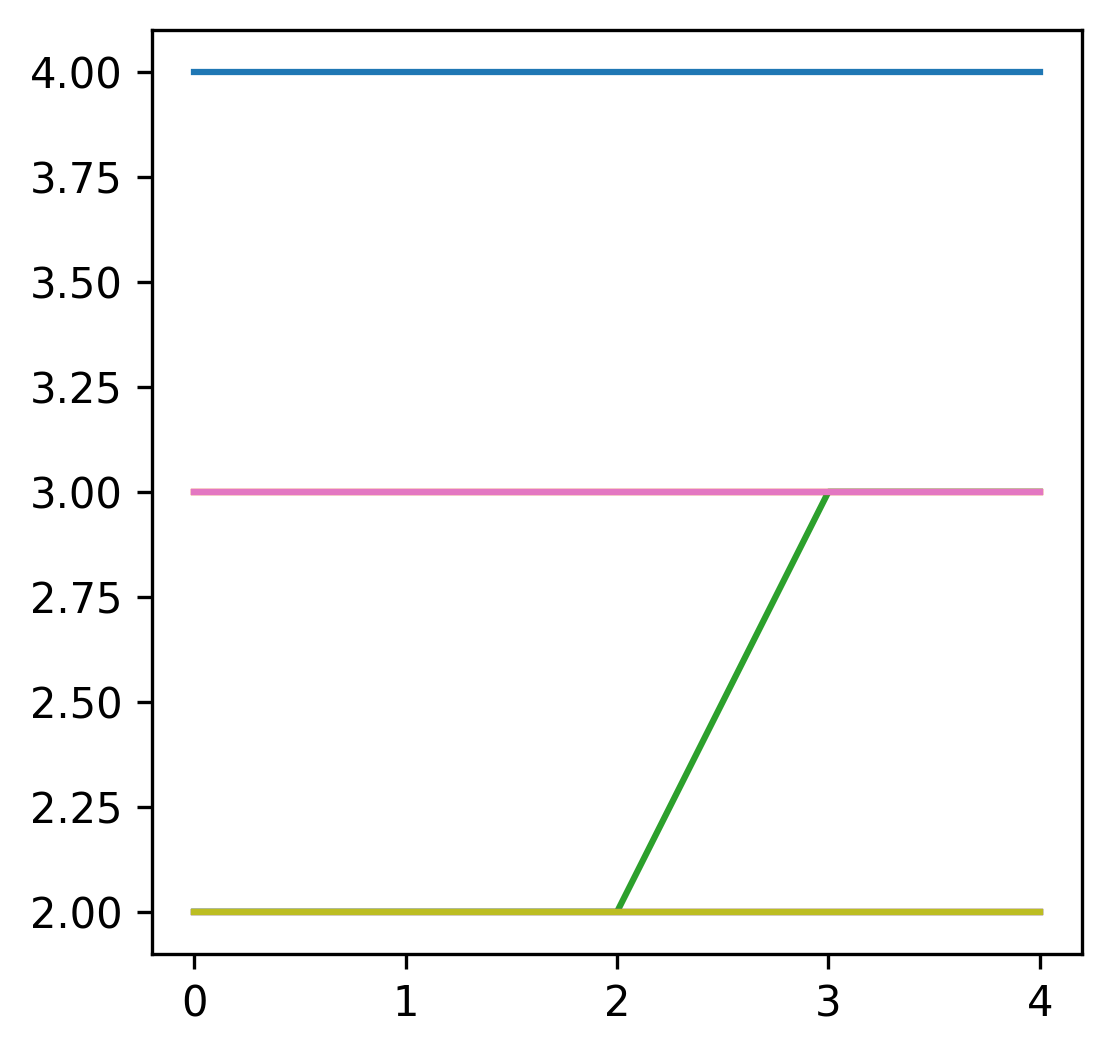

In [9]:
for d in d_lst:
    plt.plot(range(len(d)), d)

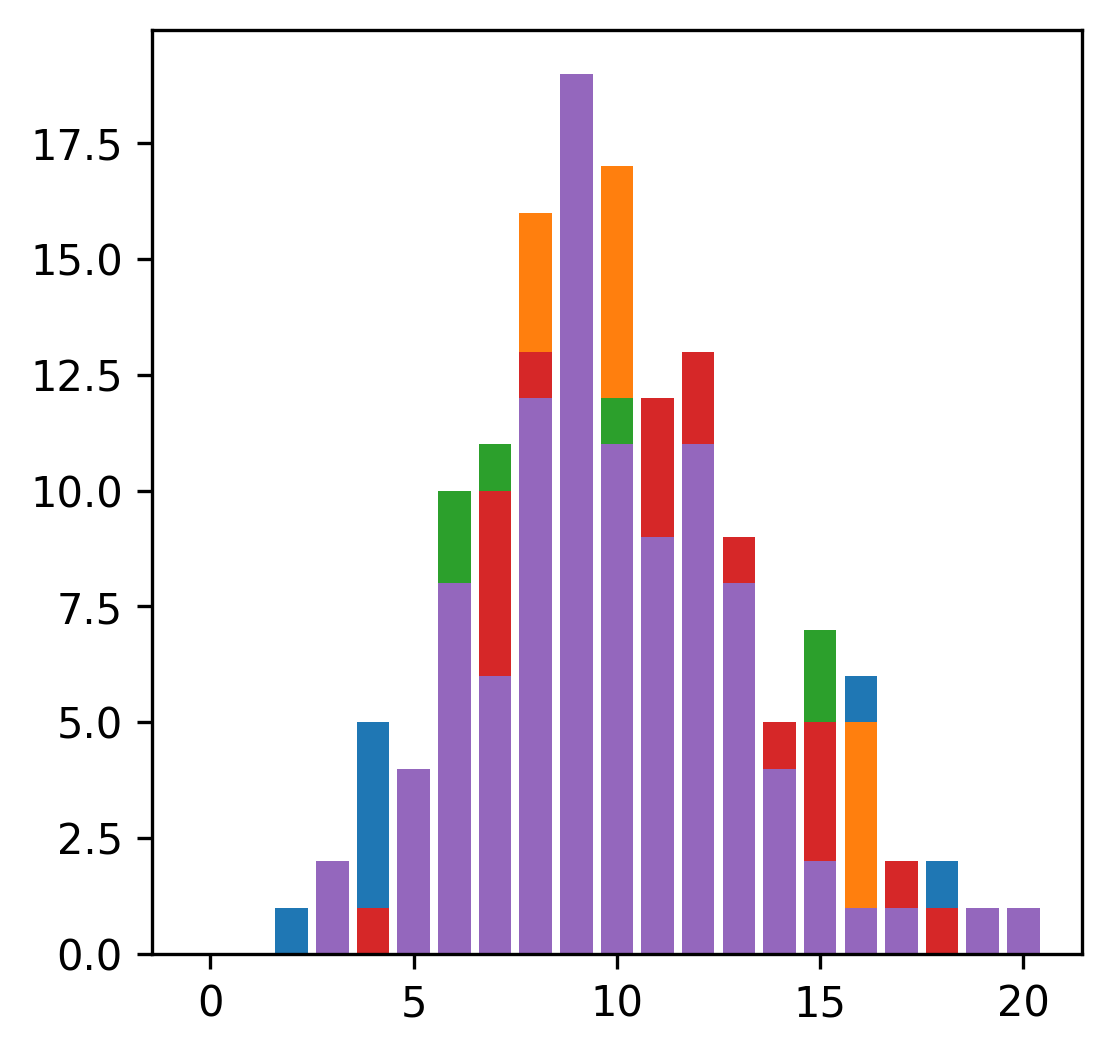

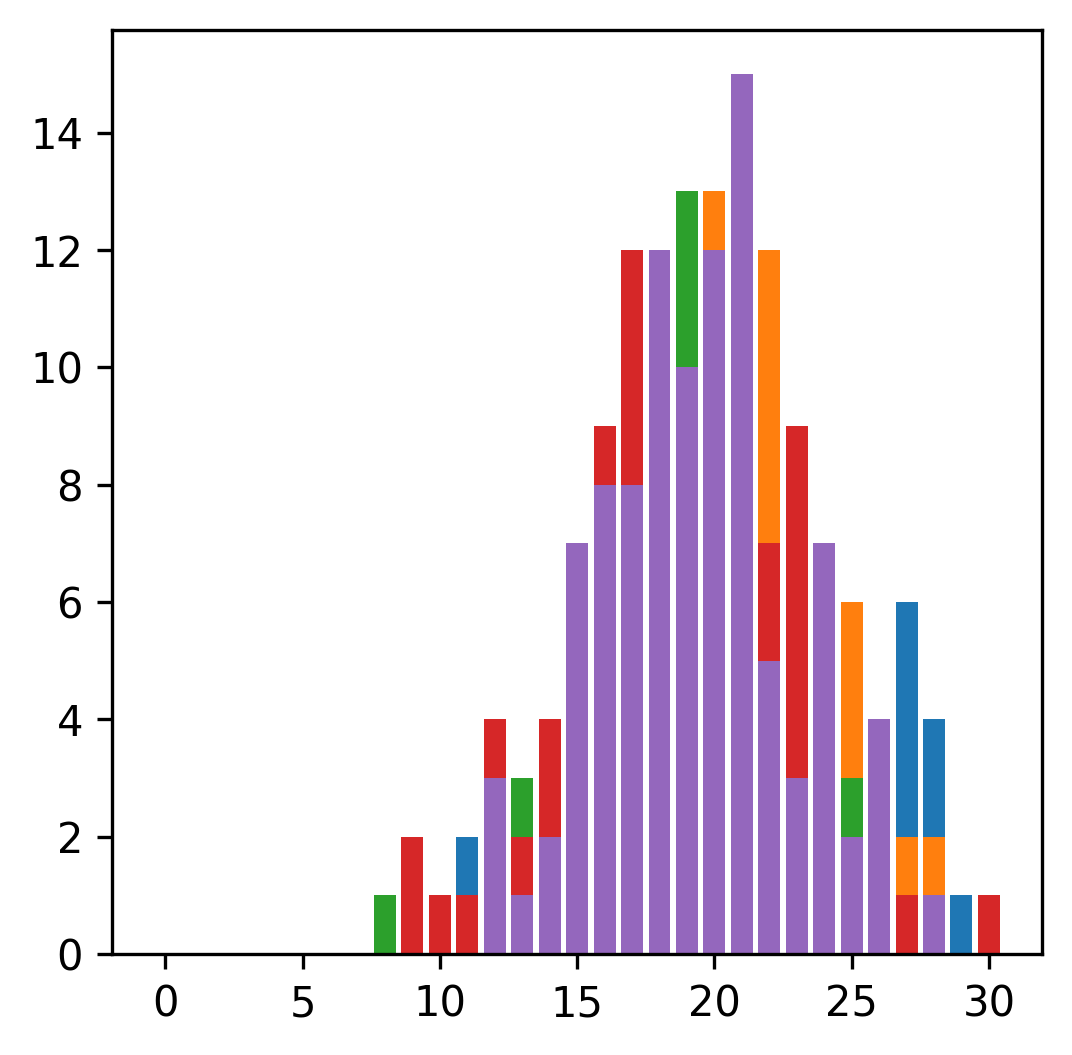

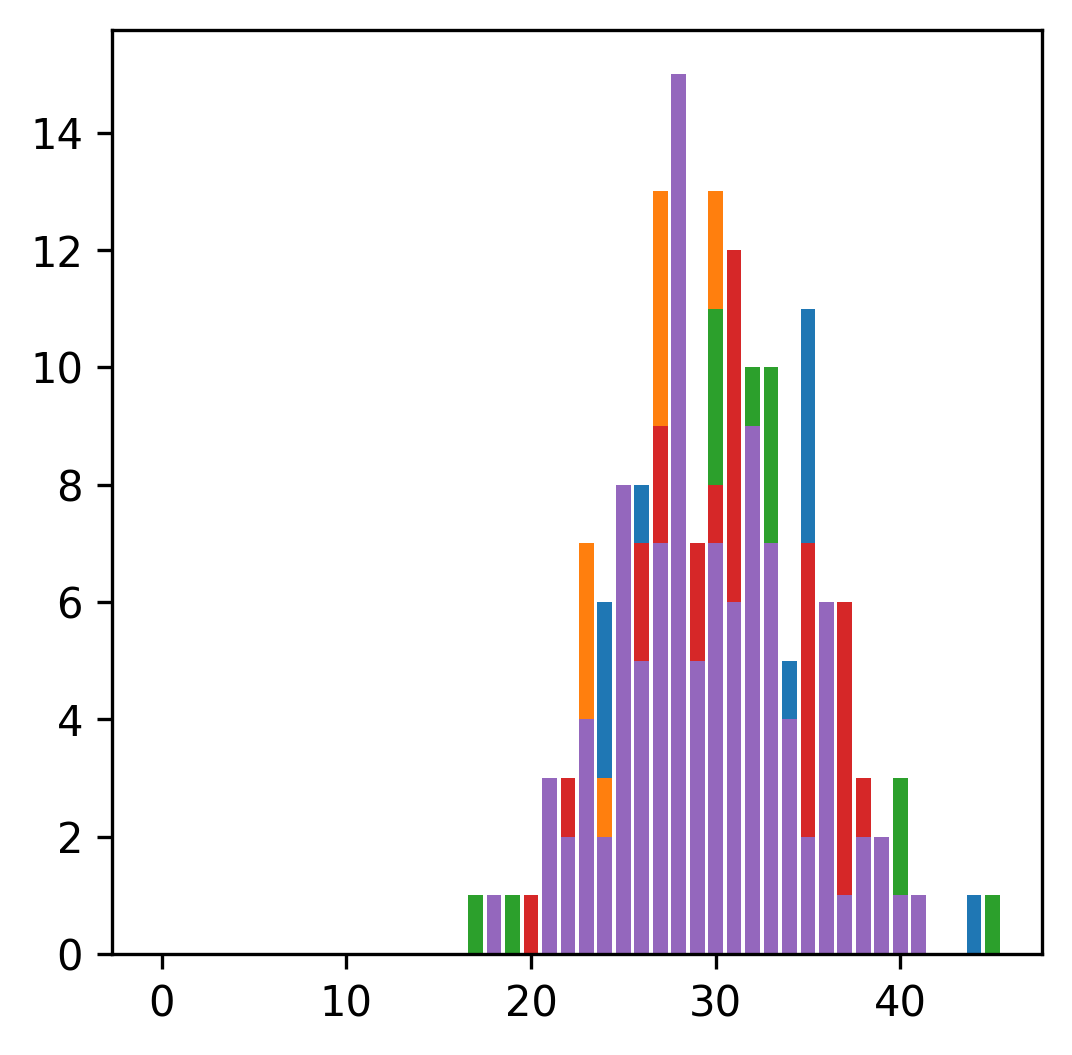

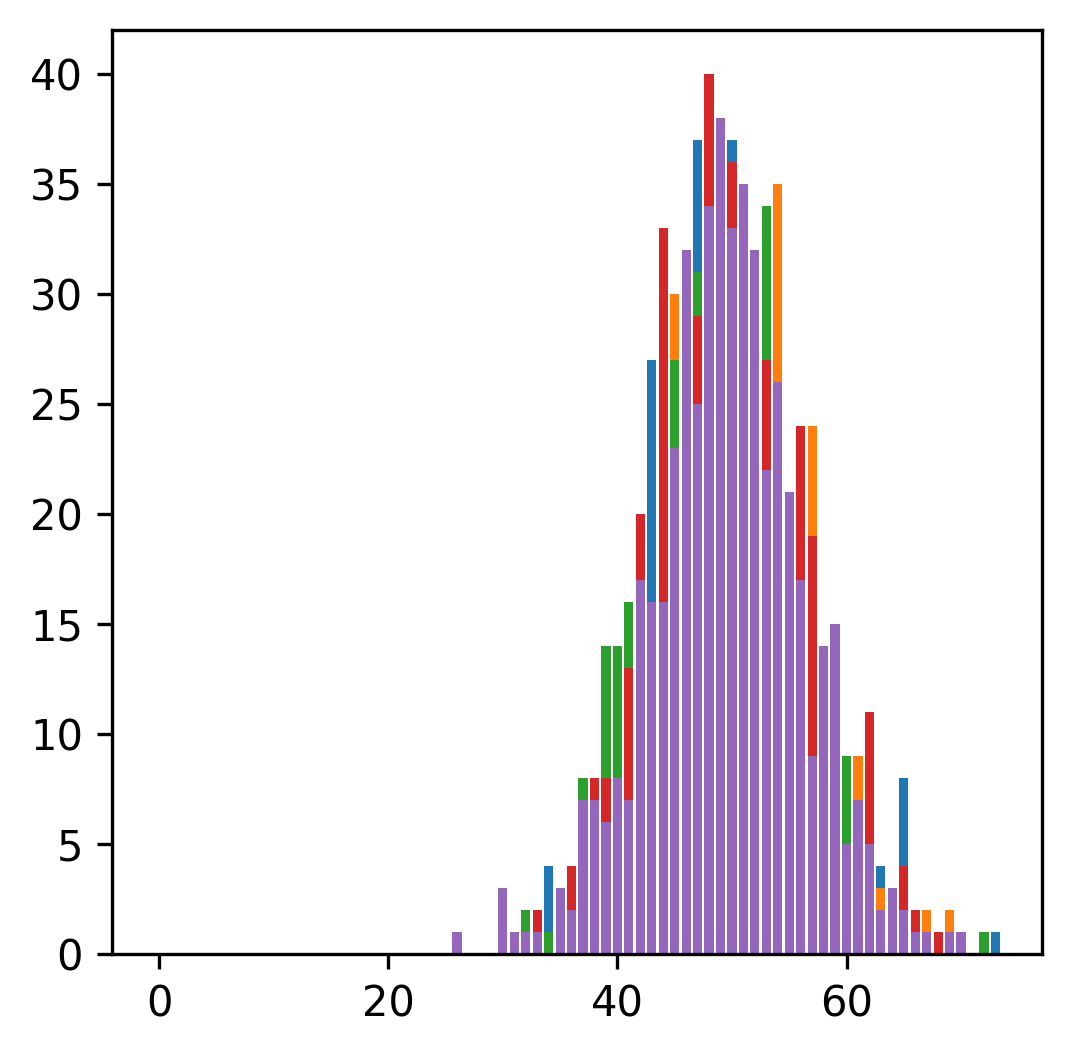

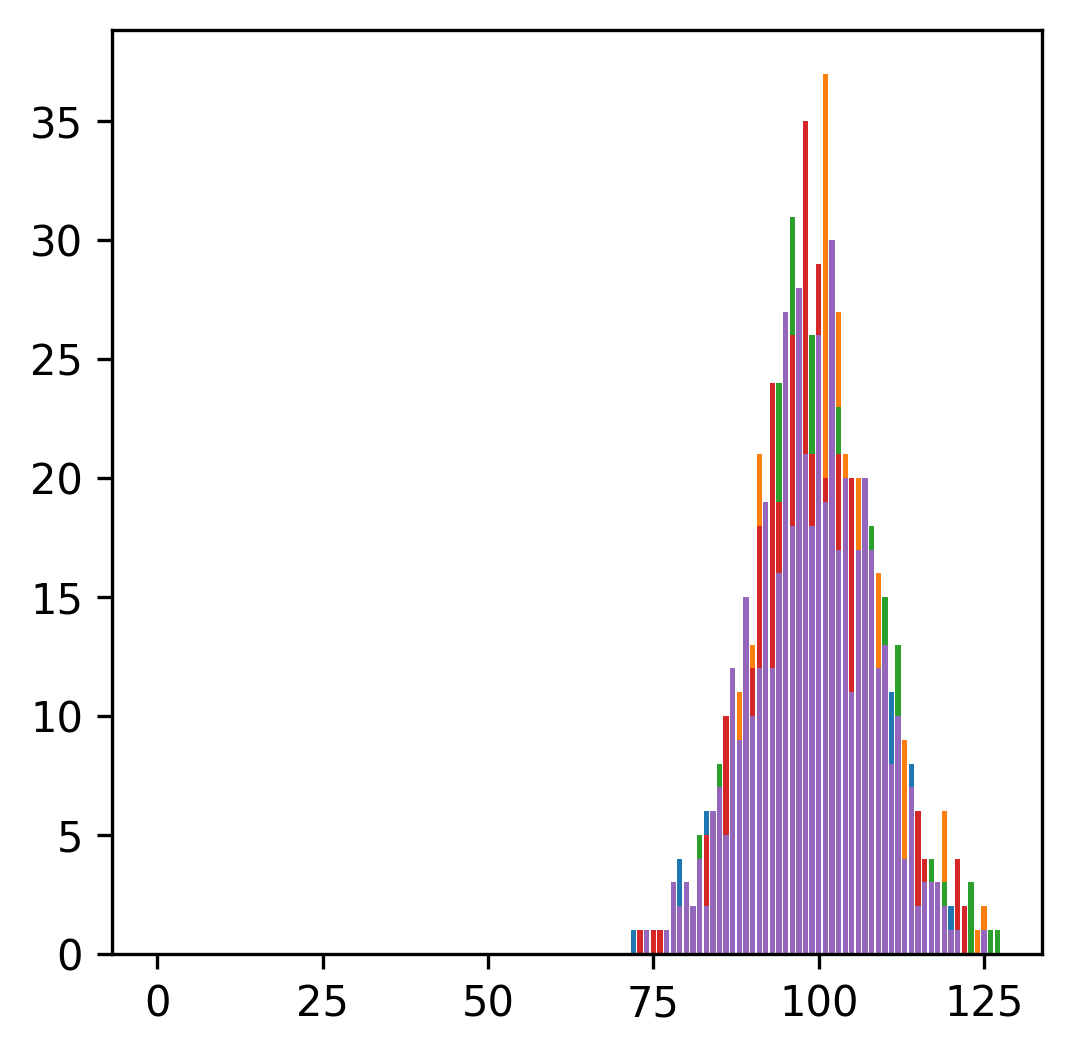

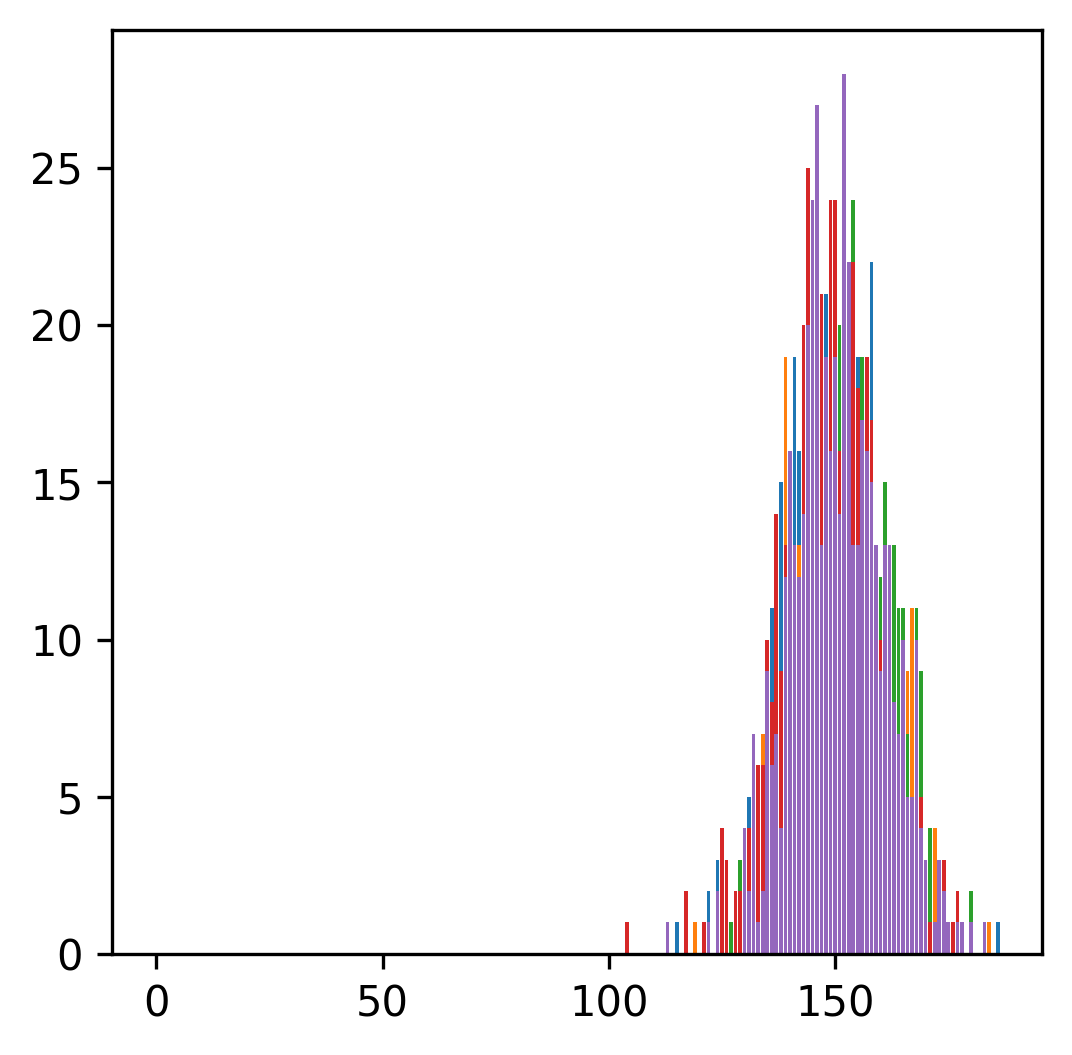

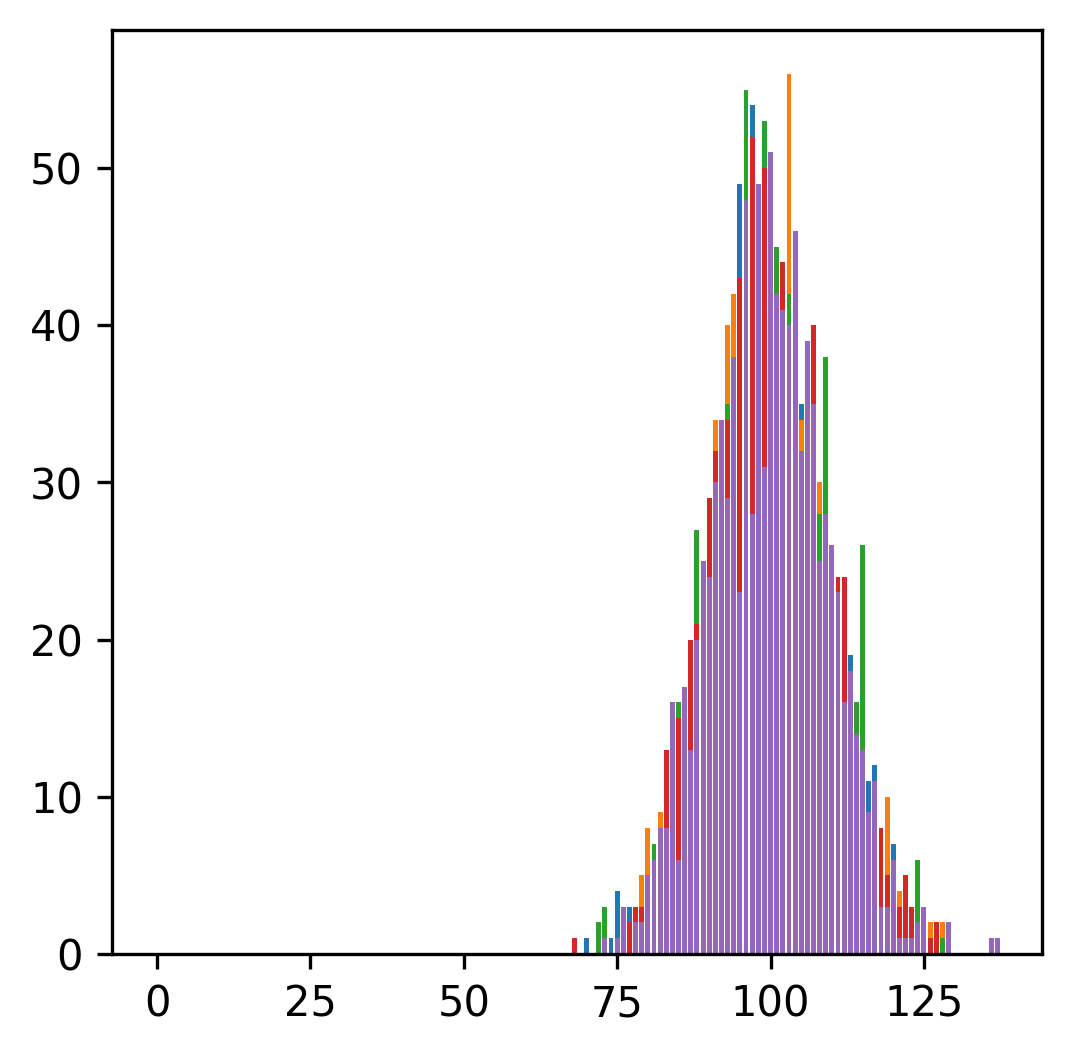

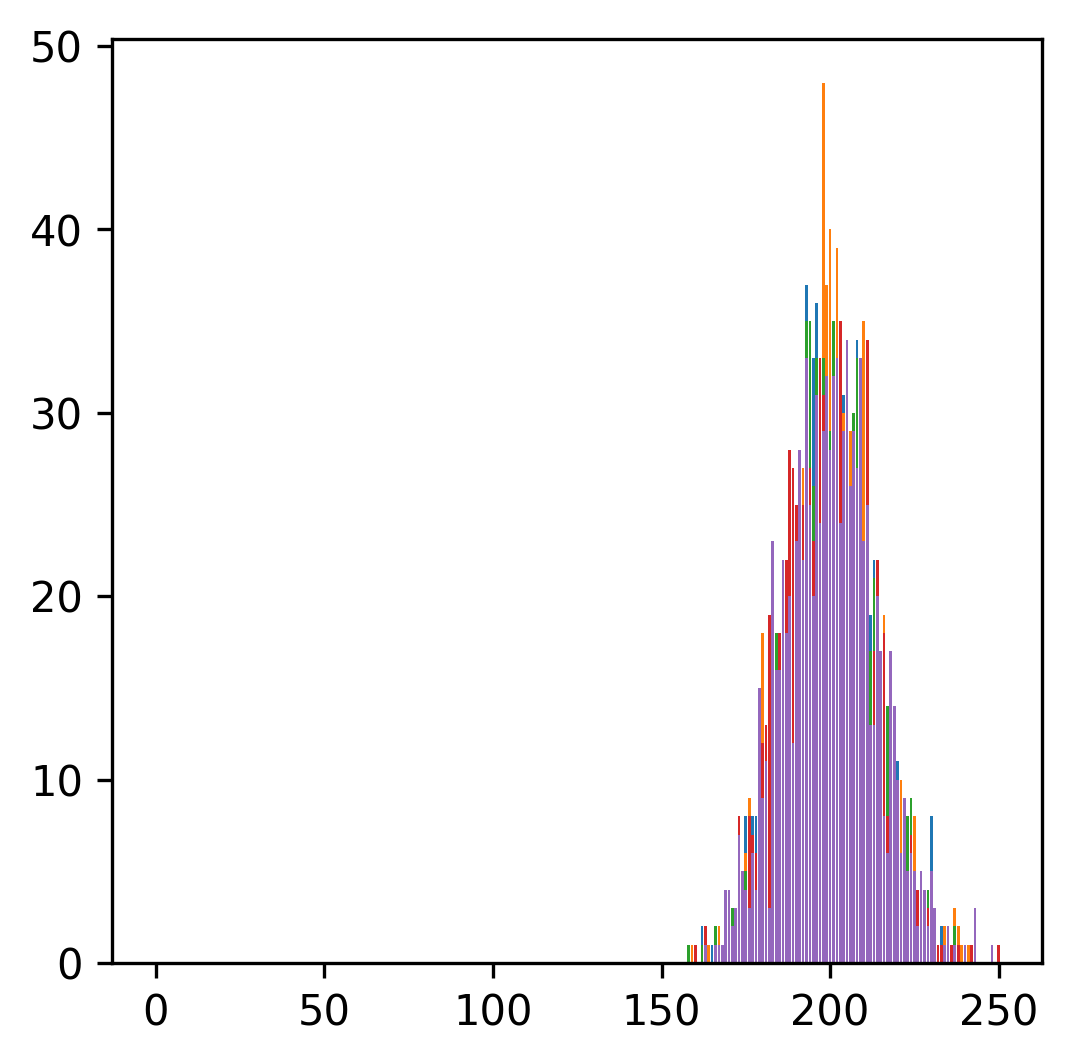

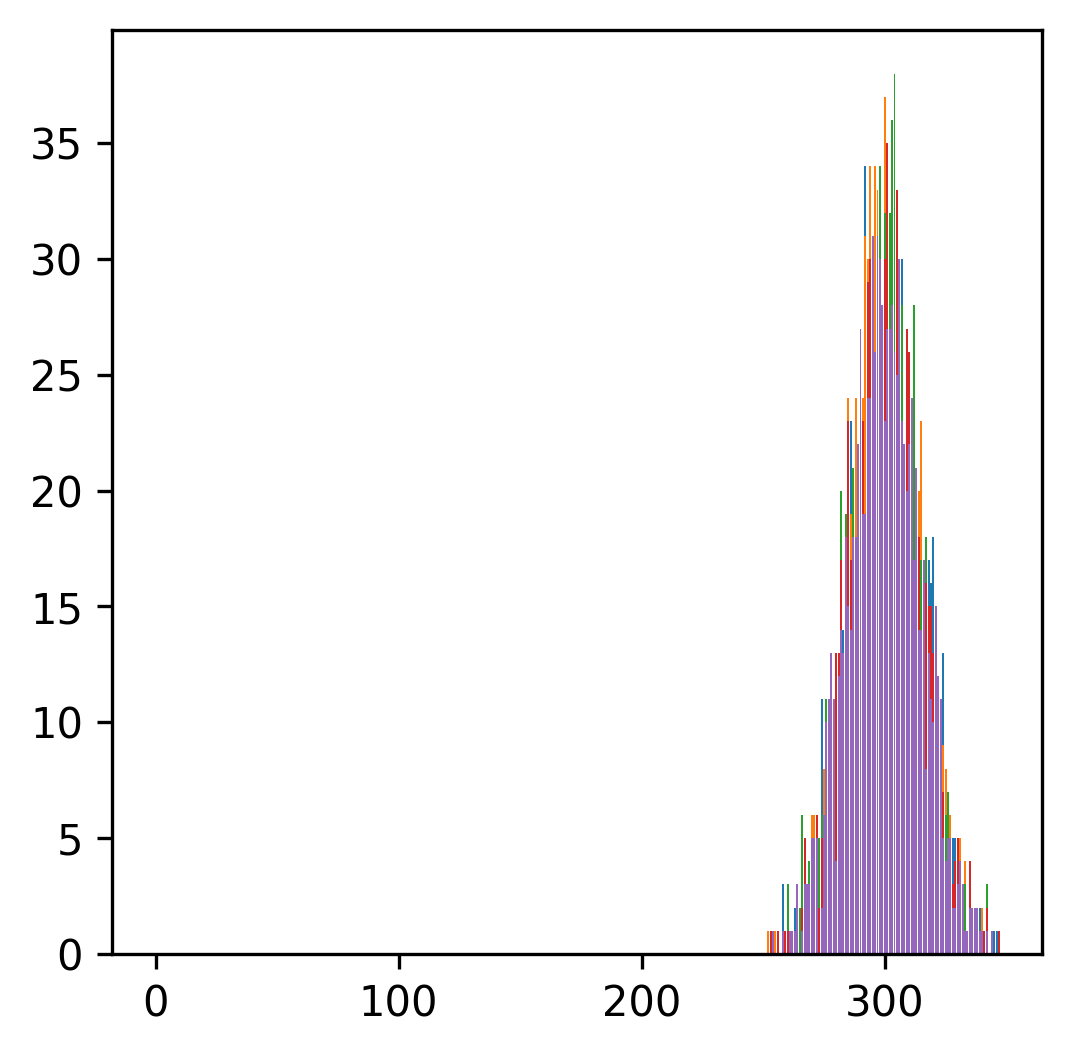

In [10]:
for deg in deg_lst:
    for q in deg:
        plt.bar(range(len(q)), q)
    plt.show()

In [11]:
m_vals = [1, 2, 5]
C_lst, d_lst, l_lst, deg_lst, params, _ = gen.batch_analysis(N=N_vals, m=m_vals, graph_type="ba", iterations=5)
graph_ba = _[-1][-1]

  0%|          | 0/9 [00:00<?, ?it/s]

In [12]:
m_vals = [2, 4, 5]
C_lst, d_lst, l_lst, deg_lst, params, _ = gen.batch_analysis(N=N_vals, p=p_vals, k=m_vals, graph_type="ws", iterations=5)
graph_ws = _[-1][-1]

  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

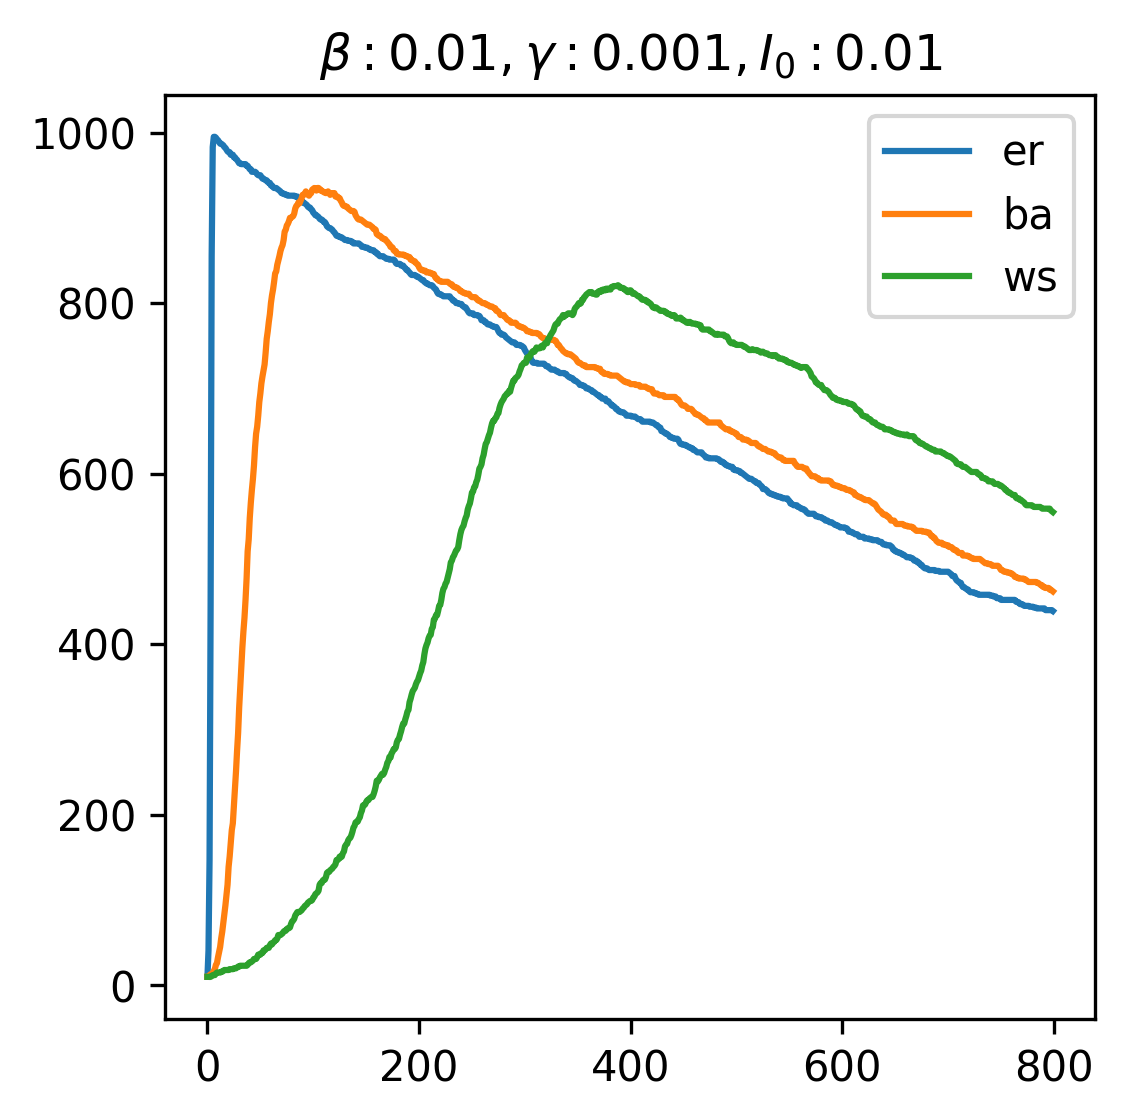

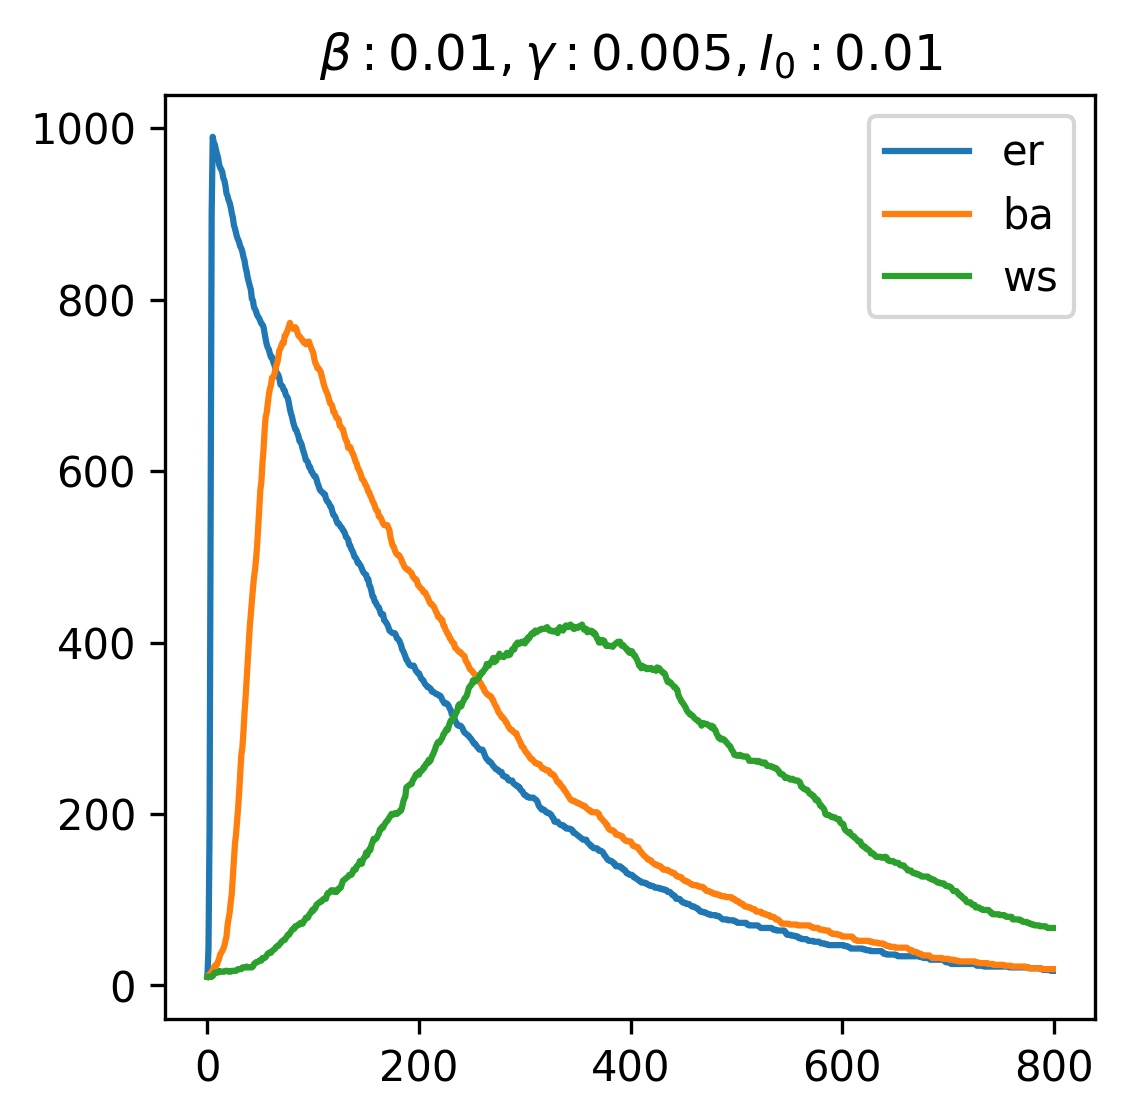

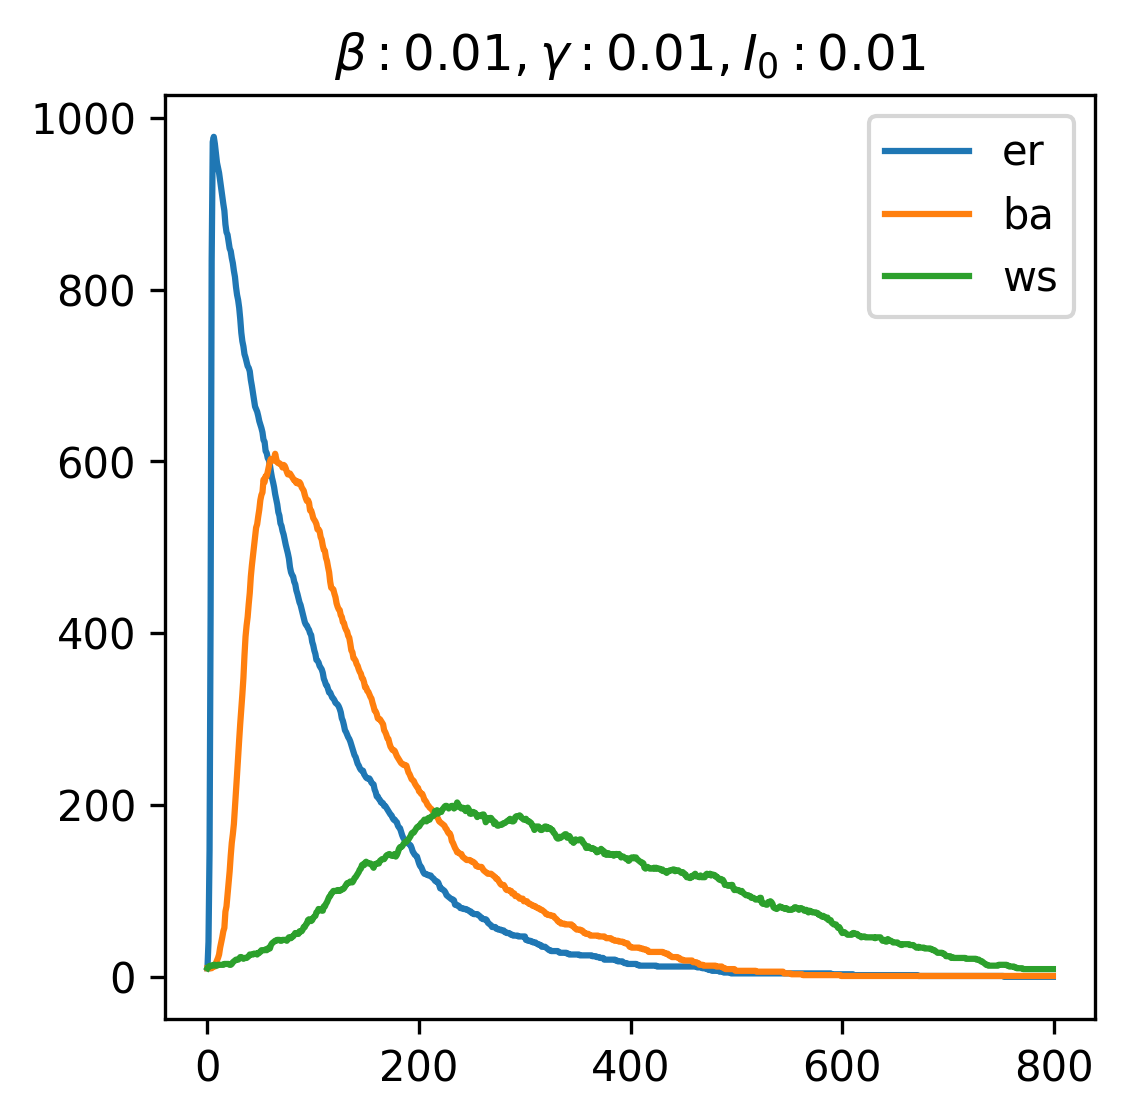

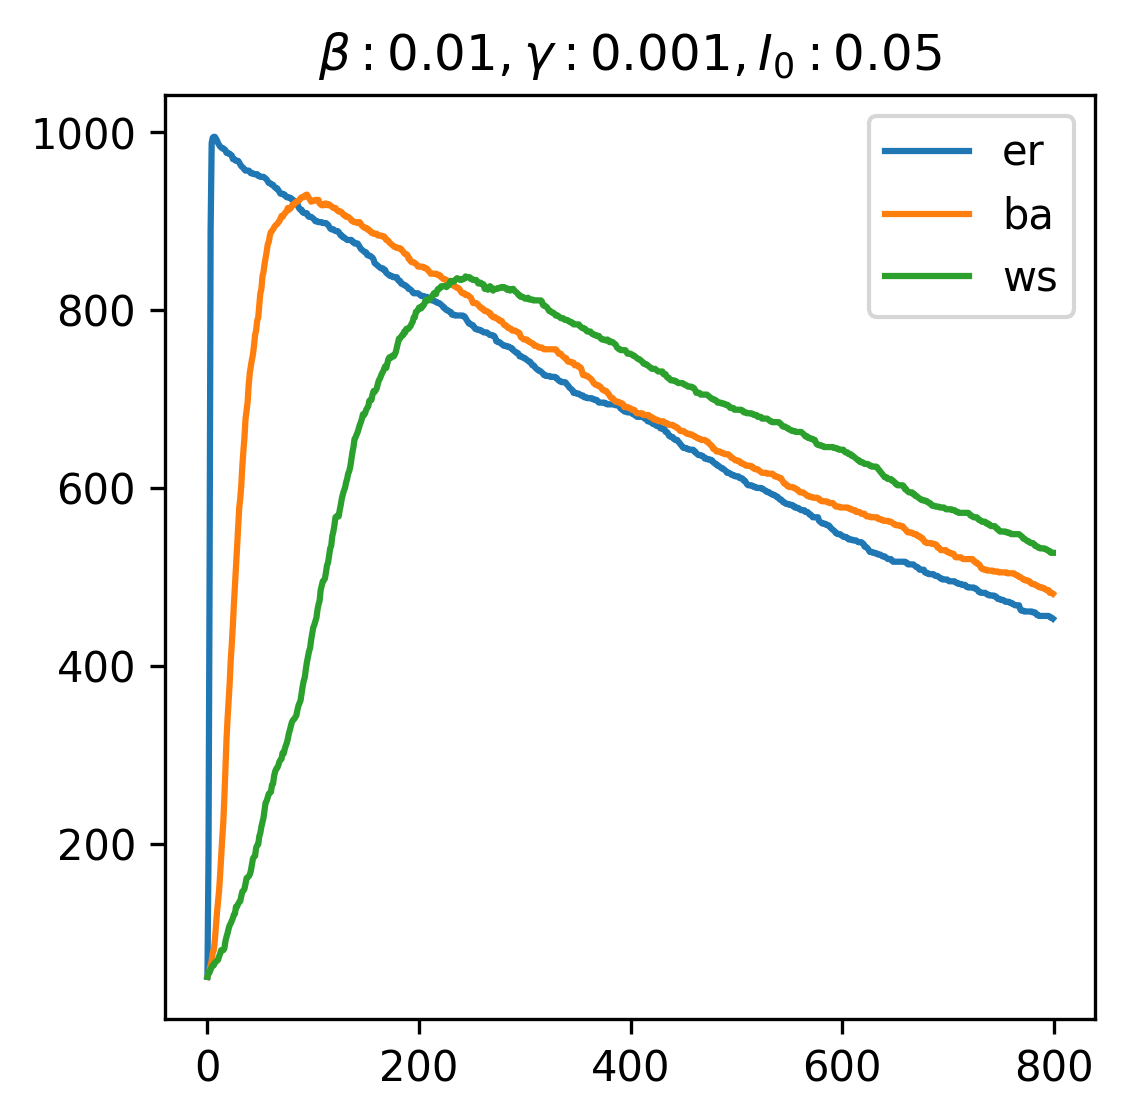

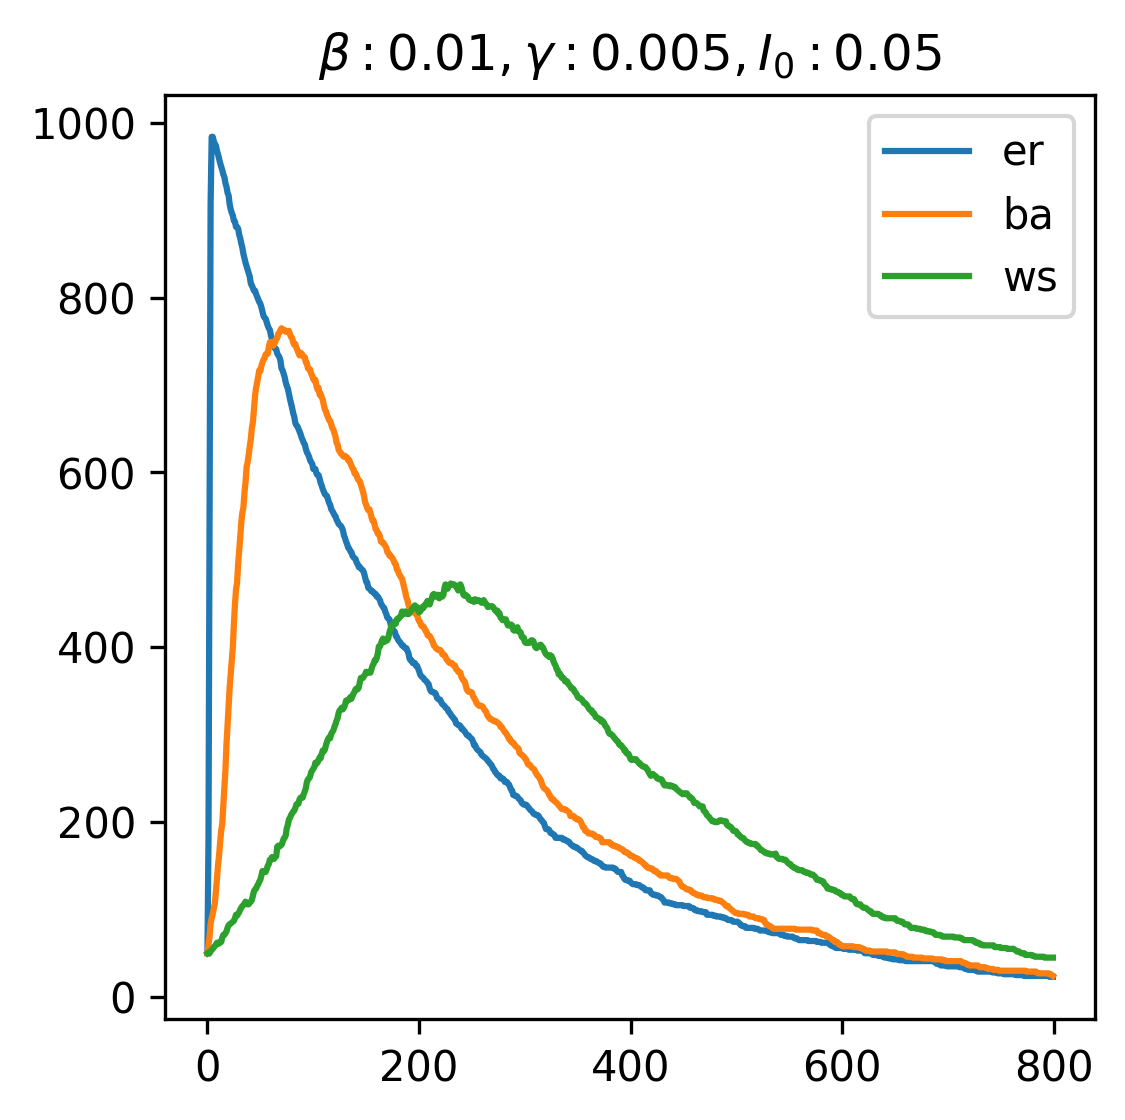

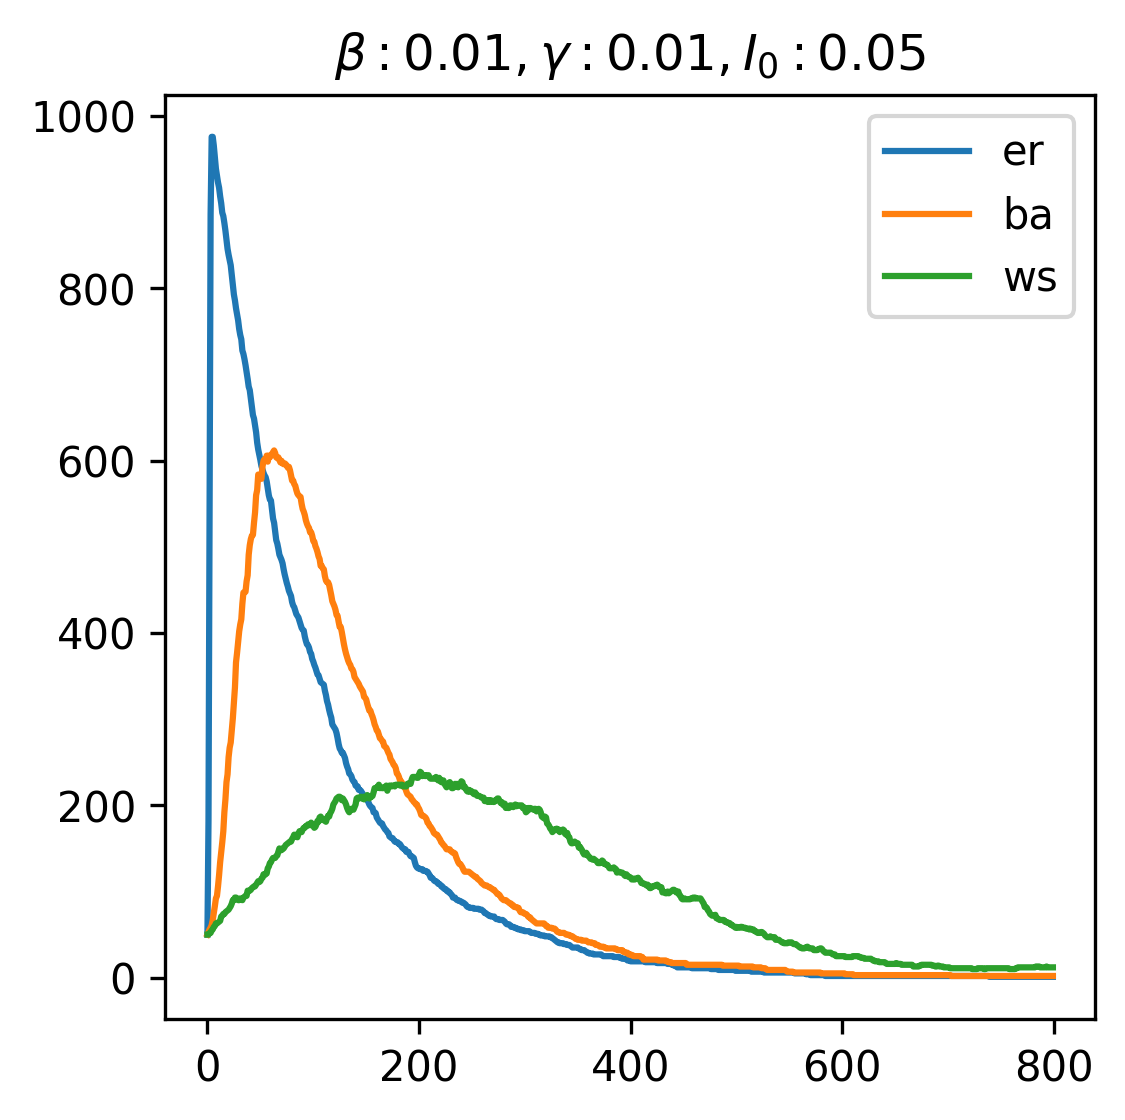

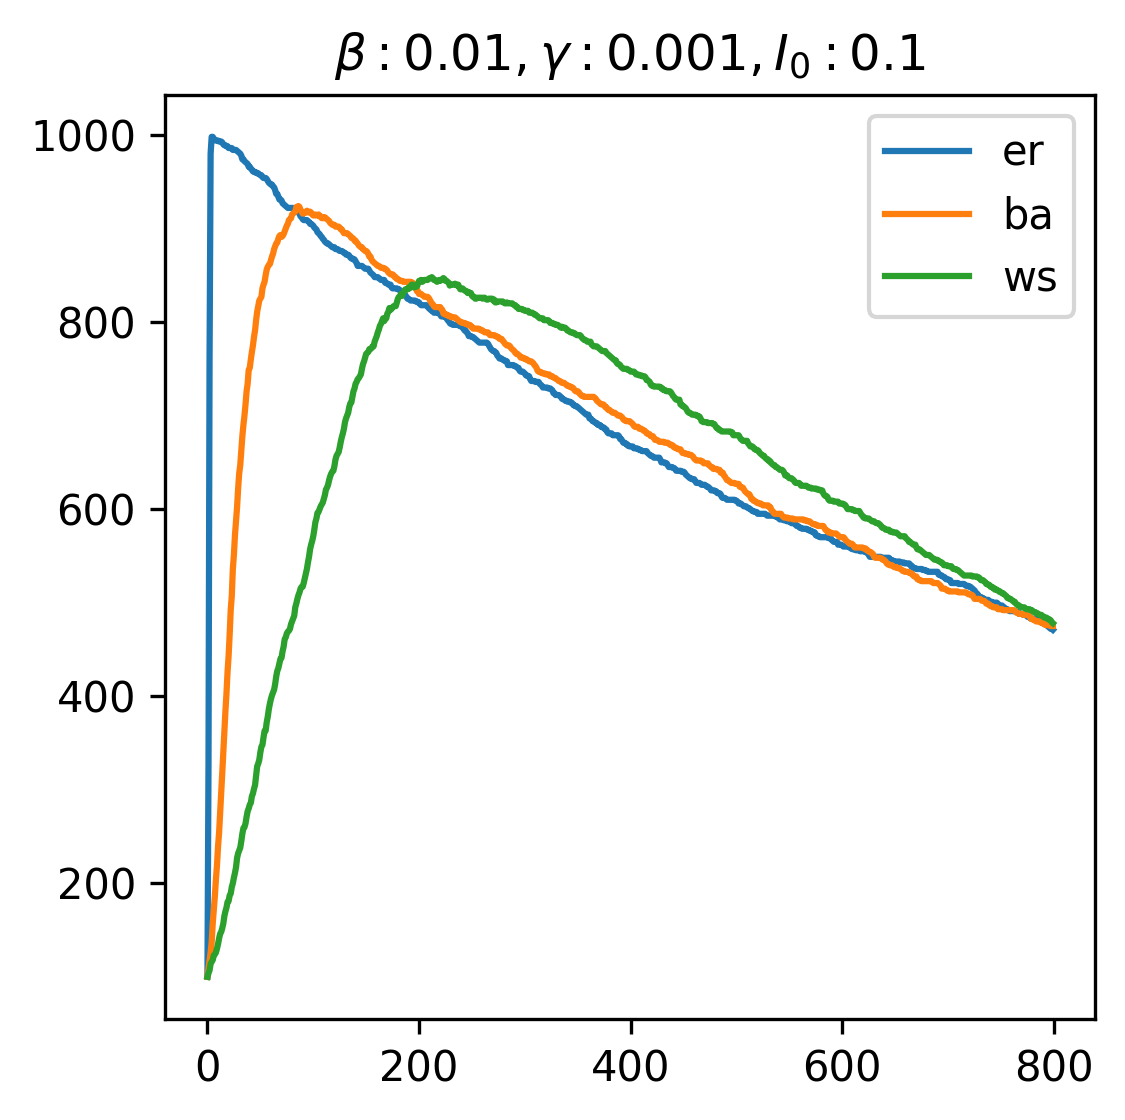

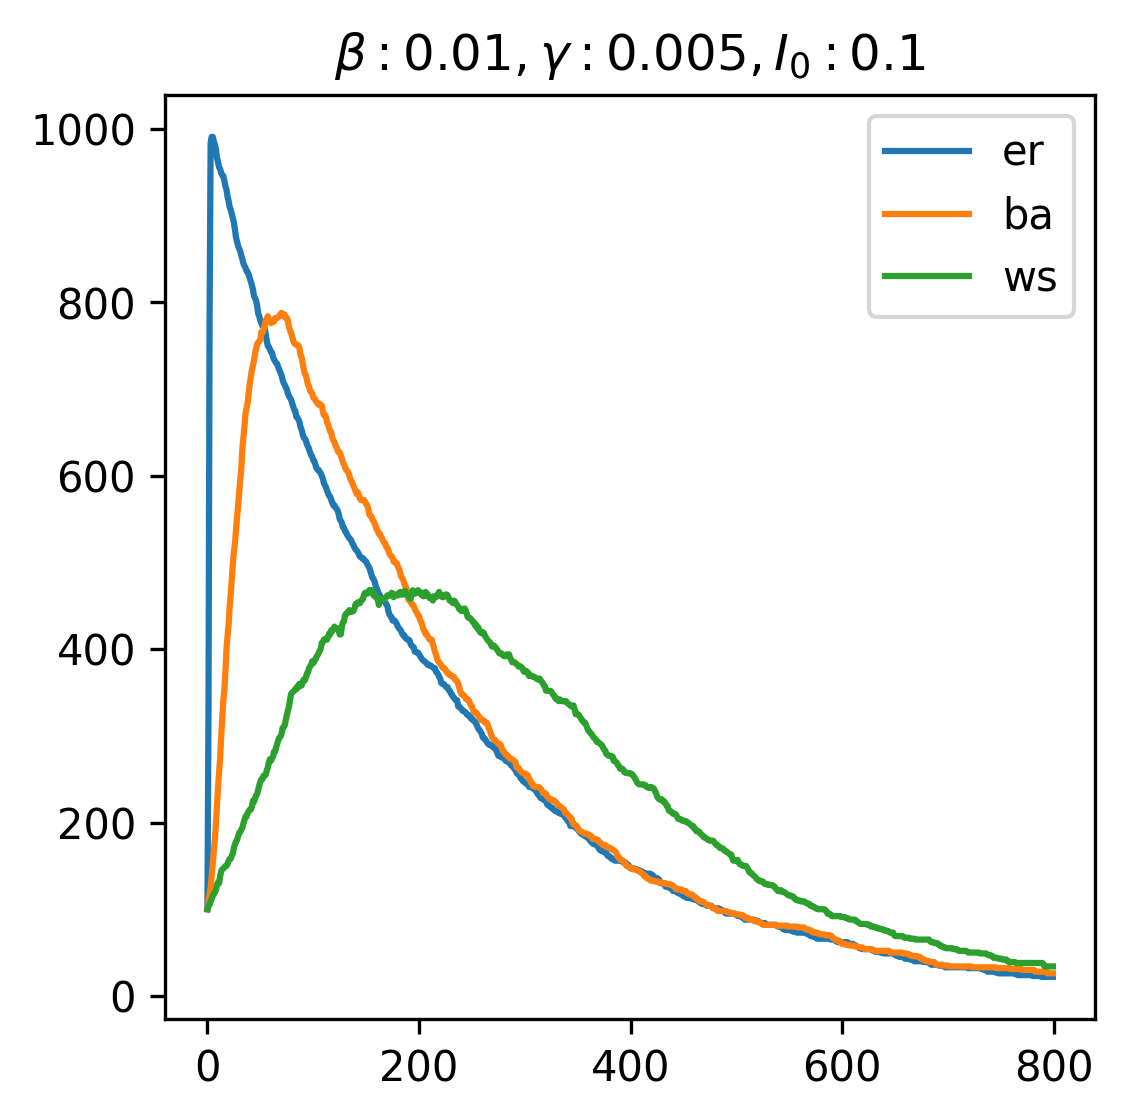

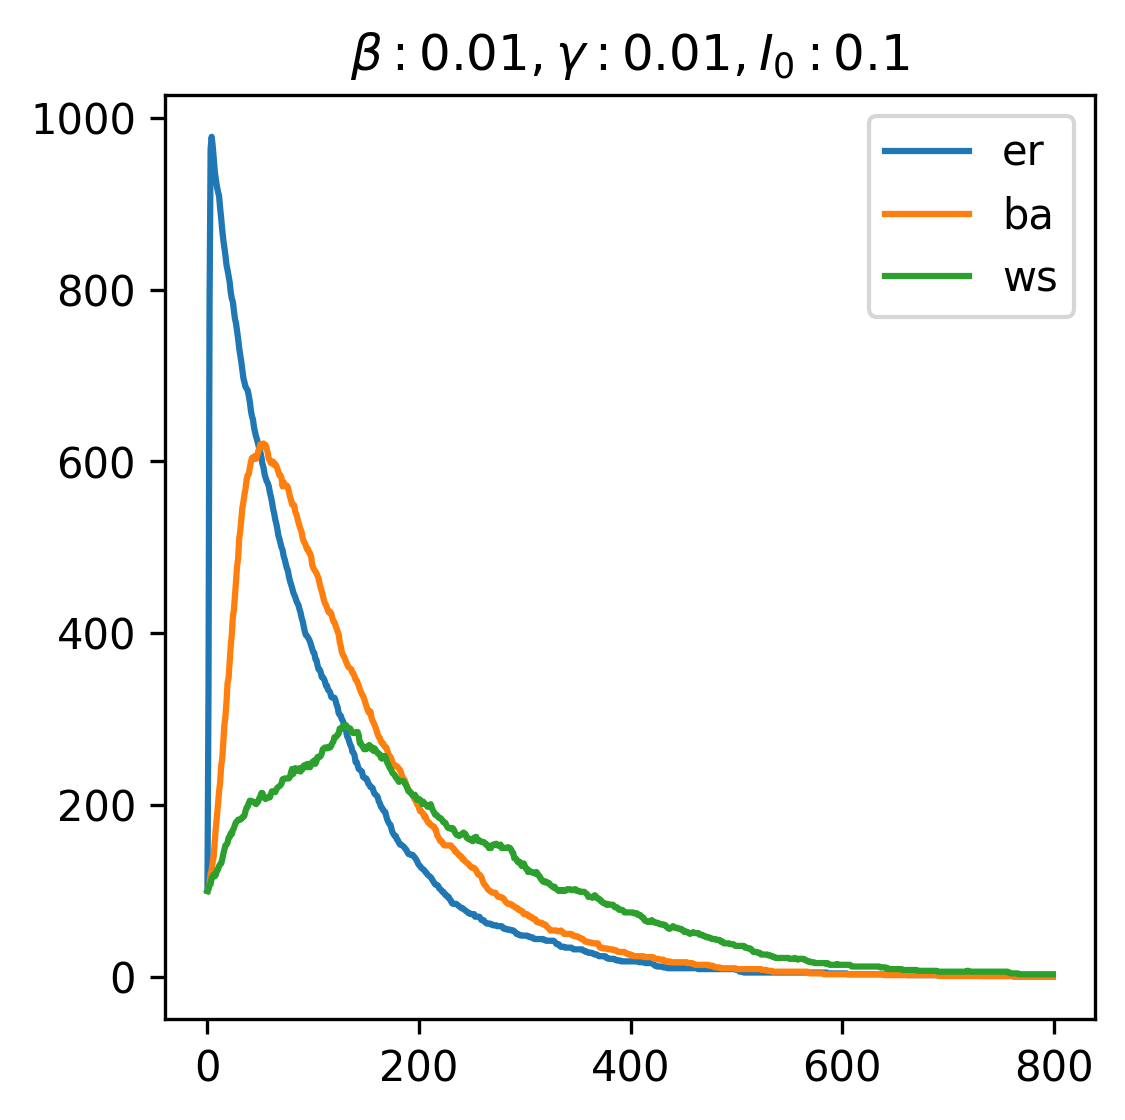

In [13]:
gamma_lst = [0.001, 0.005, 0.01]
I_0 = [0.01, 0.05, 0.1, ]
for (i, gamma) in product(I_0, gamma_lst):
    er_model = model_trend(ep.SIRModel(graph_er), 0.01, gamma, i, 800)
    ba_model = model_trend(ep.SIRModel(graph_ba), 0.01, gamma, i, 800)
    ws_model = model_trend(ep.SIRModel(graph_ws), 0.01, gamma, i, 800)
    plt.title(f"$\\beta: {0.01}, \\gamma: {gamma}, I_0: {i}$")
    plt.plot(er_model[3], er_model[1], label="er")
    plt.plot(ba_model[3], ba_model[1], label="ba")
    plt.plot(ws_model[3], ws_model[1], label="ws")
    plt.legend()
    plt.show()